In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import pandas as pd
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from sklearn import mixture
from sklearn.cluster import DBSCAN
from copy import copy

import sys

sys.path.append("..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from src import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from src import SR_Functions

SupRes_F = SR_Functions.SuperRes_Functions()

from src import render
from src import localise as _localise
from src import postprocess as _postprocess

from jupyter_bbox_widget import BBoxWidget
import ipywidgets as widgets
from io import BytesIO
from PIL import Image
import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

INFO:Constants:Logging to file: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Code/Python/pyBayerSMLM/logs/Constants_20251106_204149.log


In [2]:
data_folder = "../Camera_Calibrations/Ximea_Camera"
gain_map = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset_map = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
read_noise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

pixel_QYs = np.vstack([B, G, R])
camera_parameters = {}
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]

In [3]:
spectrum = S_F.get_dye_or_filter_data('semrock-ff01-515-lp', wavelength, dye_or_filter=False).squeeze()*S_F.get_dye_or_filter_data('ATTO 520', wavelength).squeeze()

In [16]:
photon_wavelengths = S_F.sample_photons_from_spectrum(spectrum=spectrum, wavelength=wavelength, n_photons=100)

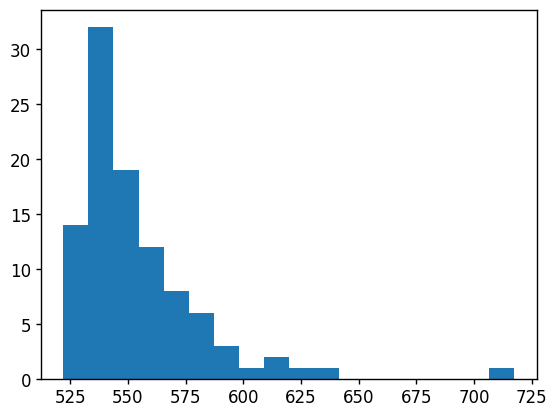

In [17]:
plt.hist(photon_wavelengths, np.histogram_bin_edges(photon_wavelengths, 'fd'));
plt.show()

In [18]:
mean_wl, colour_ratios = S_F.calculate_colourratio_from_photon_wavelengths(
      photon_wavelengths, wavelength, pixel_QYs, pixel_order=camera_parameters["pixel_order"],
    pixel_order_indices=camera_parameters["pixel_order_indices"]
  )

In [19]:
colour_ratios

array([ 0.09,  0.84,  0.07])